In [ ]:
import numpy as np

# 1. Định nghĩa trọng số (Giả định bằng nhau cho 7 tiêu chí)
# (6 tiêu chí lợi ích + 1 tiêu chí an toàn)
weights = np.array([1/7] * 7)

# 2. Tính ma trận có trọng số
weighted_matrix = normalized_matrix * weights

# 3. Xác định giải pháp lý tưởng (V+ và V-)
v_plus = weighted_matrix.max()
v_minus = weighted_matrix.min()

# 4. Tính khoảng cách Euclid tới V+ và V-
s_plus = np.sqrt(((weighted_matrix - v_plus)**2).sum(axis=1))
s_minus = np.sqrt(((weighted_matrix - v_minus)**2).sum(axis=1))

# 5. Tính điểm TOPSIS (Ci) và Xếp hạng
df['topsis_score'] = s_minus / (s_plus + s_minus)
df['rank'] = df['topsis_score'].rank(ascending=False)

# 6. Hiển thị kết quả xếp hạng
# Ưu tiên lấy tên tiếng Việt nếu có
name_col = 'sector_name_vi' if 'sector_name_vi' in df.columns else 'sector'
final_ranking = df[[name_col, 'topsis_score', 'rank']].sort_values(by='rank')

print("KẾT QUẢ XẾP HẠNG TOPSIS:")
display(final_ranking)

KẾT QUẢ XẾP HẠNG TOPSIS:


,sector_name_vi,topsis_score,rank
1,Công nghiệp chế biến chế tạo,0.722927,1.0
7,Thông tin-Truyền thông-CNTT,0.564942,2.0
0,Nông-Lâm-Thủy sản,0.459462,3.0
4,Bán buôn-bán lẻ,0.438109,4.0
6,Logistics-Vận tải-Kho bãi,0.435612,5.0
5,Tài chính-Ngân hàng-Bảo hiểm,0.423780,6.0
9,Y tế-Chăm sóc sức khỏe,0.421808,7.0
8,Giáo dục-Đào tạo,0.414146,8.0
2,Xây dựng,0.387607,9.0
3,Khai khoáng,0.075543,10.0


In [ ]:
import numpy as np
import pandas as pd

# 1. Thiết lập trọng số theo cấu trúc PriorityParams bạn cung cấp
# Các trọng số này tập trung mạnh vào Spillover (0.2) và AI Readiness (0.2)
custom_weights = {
    'growth_rate_2024_pct': 0.15,
    'gdp_share_2024_pct': 0.15,
    'spillover_coef_0_1': 0.20,
    'export_billion_USD': 0.15,
    'labor_million': 0.10,
    'ai_readiness_0_100': 0.20,
    'automation_risk_pct': 0.15 # Đây là safety_score đã được chuẩn hóa thuận
}

# Chuyển dictionary thành array theo đúng thứ tự cột trong normalized_matrix
weight_array = np.array([custom_weights[col] for col in normalized_matrix.columns])
weight_array = weight_array / weight_array.sum()

# 2. Tính điểm Priority (Weighted Sum Model - tương tự logic trong route calculate)
df['priority_score'] = normalized_matrix.values @ weight_array

# 3. Xếp hạng lại
df['priority_rank'] = df['priority_score'].rank(ascending=False)

# 4. Hiển thị so sánh
name_col = 'sector_name_vi' if 'sector_name_vi' in df.columns else 'sector'
comparison = df[[name_col, 'priority_score', 'priority_rank']].sort_values('priority_rank')

print("KẾT QUẢ XẾP HẠNG THEO TRỌNG SỐ TÙY CHỈNH (POLICY-BASED):")
display(comparison)

KẾT QUẢ XẾP HẠNG THEO TRỌNG SỐ TÙY CHỈNH (POLICY-BASED):


,sector_name_vi,priority_score,priority_rank
1,Công nghiệp chế biến chế tạo,0.772767,1.0
7,Thông tin-Truyền thông-CNTT,0.666137,2.0
5,Tài chính-Ngân hàng-Bảo hiểm,0.436082,3.0
6,Logistics-Vận tải-Kho bãi,0.430254,4.0
4,Bán buôn-bán lẻ,0.420202,5.0
9,Y tế-Chăm sóc sức khỏe,0.400859,6.0
8,Giáo dục-Đào tạo,0.394360,7.0
0,Nông-Lâm-Thủy sản,0.373505,8.0
2,Xây dựng,0.323960,9.0
3,Khai khoáng,0.044476,10.0


DIỄN BIẾN TOP 3 THEO TRỌNG SỐ AI:

w_AI = 0.05: Công nghiệp chế biến chế tạo, Thông tin-Truyền thông-CNTT, Logistics-Vận tải-Kho bãi
w_AI = 0.10: Công nghiệp chế biến chế tạo, Thông tin-Truyền thông-CNTT, Logistics-Vận tải-Kho bãi
w_AI = 0.15: Công nghiệp chế biến chế tạo, Thông tin-Truyền thông-CNTT, Logistics-Vận tải-Kho bãi
w_AI = 0.20: Công nghiệp chế biến chế tạo, Thông tin-Truyền thông-CNTT, Tài chính-Ngân hàng-Bảo hiểm
w_AI = 0.25: Công nghiệp chế biến chế tạo, Thông tin-Truyền thông-CNTT, Tài chính-Ngân hàng-Bảo hiểm
w_AI = 0.30: Công nghiệp chế biến chế tạo, Thông tin-Truyền thông-CNTT, Tài chính-Ngân hàng-Bảo hiểm
w_AI = 0.35: Thông tin-Truyền thông-CNTT, Công nghiệp chế biến chế tạo, Tài chính-Ngân hàng-Bảo hiểm
w_AI = 0.40: Thông tin-Truyền thông-CNTT, Công nghiệp chế biến chế tạo, Tài chính-Ngân hàng-Bảo hiểm


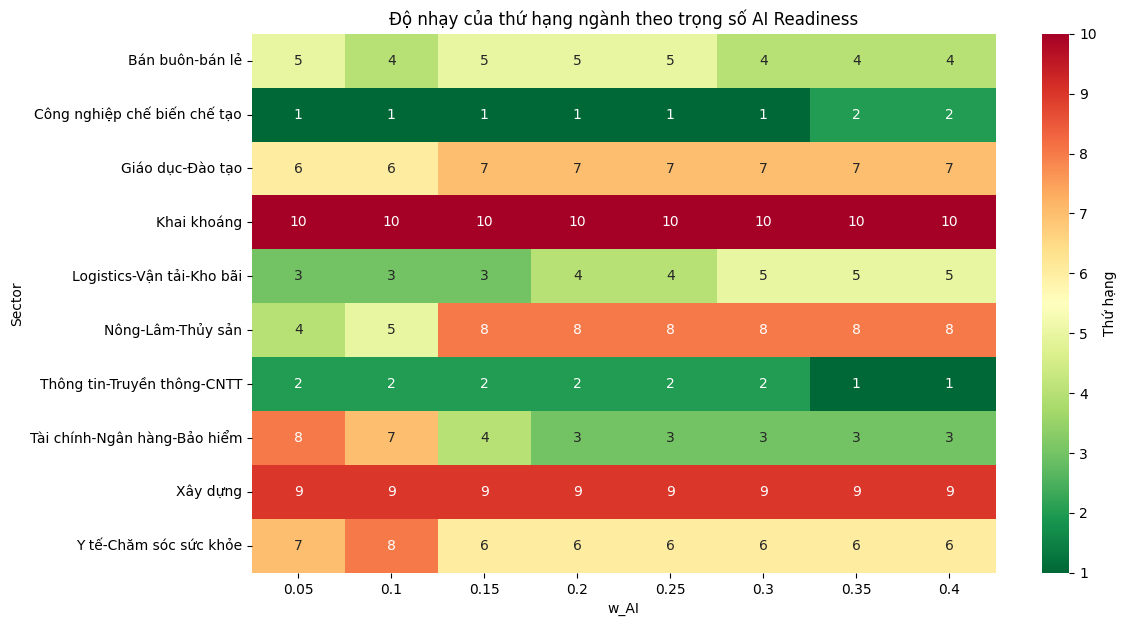

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập mảng trọng số cần test cho w_AI
ai_weights = np.arange(0.05, 0.45, 0.05)

# 2. Khai báo các trọng số gốc từ yêu cầu trước đó (tổng = 1.0)
# Trọng số cũ: AI=0.2, Spillover=0.2, Growth=0.15, GDP=0.15, Export=0.15, Risk=0.15, Labor=0.10
base_weights = {
    'growth_rate_2024_pct': 0.15,
    'gdp_share_2024_pct': 0.15,
    'spillover_coef_0_1': 0.20,
    'export_billion_USD': 0.15,
    'labor_million': 0.10,
    'automation_risk_pct': 0.15
}
sum_base = sum(base_weights.values())

results = []
sector_names = df['sector_name_vi'].values

# 3. Chạy các kịch bản
for w_ai in ai_weights:
    remaining_w = 1.0 - w_ai
    factor = remaining_w / sum_base

    current_total_weights = {k: v * factor for k, v in base_weights.items()}
    current_total_weights['ai_readiness_0_100'] = w_ai

    # Tính điểm dựa trên normalized_matrix
    weights_vec = np.array([current_total_weights[col] for col in normalized_matrix.columns])
    scores = normalized_matrix.values @ weights_vec

    temp_df = pd.DataFrame({
        'Sector': sector_names,
        'w_AI': round(w_ai, 2),
        'Score': scores
    })
    temp_df['Rank'] = temp_df['Score'].rank(ascending=False, method='min')
    results.append(temp_df)

df_sensitivity = pd.concat(results)

# 4. Hiển thị diễn biến Top 3
print("DIỄN BIẾN TOP 3 THEO TRỌNG SỐ AI:\n")
for w in ai_weights:
    w_r = round(w, 2)
    top3 = df_sensitivity[df_sensitivity['w_AI'] == w_r].sort_values('Rank').head(3)
    print(f"w_AI = {w_r:.2f}: {', '.join(top3['Sector'].tolist())}")

# 5. Vẽ Heatmap thứ hạng
plt.figure(figsize=(12, 7))
pivot_ranks = df_sensitivity.pivot(index='Sector', columns='w_AI', values='Rank')
sns.heatmap(pivot_ranks, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={'label': 'Thứ hạng'})
plt.title('Độ nhạy của thứ hạng ngành theo trọng số AI Readiness')
plt.show()